# FIFA World Cup 2026 - Semifinal & Champion Prediction
### A Machine Learning + Business Intelligence Project

**Student project - Management Information Systems**

This notebook predicts the outcome of the FIFA World Cup 2026 semifinals, the
final, the third-place match, and the overall champion. It also produces some
simple business insights for sponsors and marketers.

**The four semifinalists (confirmed, real fixtures):**
- Semifinal 1: **France vs Spain** - 14 July 2026
- Semifinal 2: **Argentina vs England** - 15 July 2026
- Third-place match - 18 July 2026
- Final - 19 July 2026

All match data used in this notebook is real historical data (matches from the
year 2000 to today, 25,445 matches), taken from a public football results
dataset. Business statistics (market value, FIFA ranking, social media
followers) are also real and come from published sources listed in the
README file.


## Step 1: Import Libraries

In [1]:
# Basic libraries for working with data
import pandas as pd
import numpy as np

# Libraries for making charts
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Libraries for building and testing machine learning models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Library for saving the trained model so app.py can use it later
import pickle
import json

# Make the charts look nicer
sns.set_theme(style="whitegrid")

# Stop warning messages from cluttering the notebook
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")


All libraries imported successfully


## Step 2: Load Dataset

We load two files:
1. `results.csv` - real international football match results from the year 2000 to today
2. `team_business_stats.csv` - real business data (market value, FIFA ranking, social media) for the 4 semifinalist teams


In [2]:
match_data = pd.read_csv("../data/results.csv")
business_data = pd.read_csv("../data/team_business_stats.csv")

print("Match data shape:", match_data.shape)
print("Business data shape:", business_data.shape)


Match data shape: (25445, 9)
Business data shape: (4, 8)


In [3]:
match_data.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,2000-01-04,Egypt,Togo,2.0,1.0,Friendly,Aswan,Egypt,False
1,2000-01-07,Tunisia,Togo,7.0,0.0,Friendly,Tunis,Tunisia,False
2,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,Friendly,Port of Spain,Trinidad and Tobago,False
3,2000-01-09,Burkina Faso,Gabon,1.0,1.0,Friendly,Ouagadougou,Burkina Faso,False
4,2000-01-09,Guatemala,Armenia,1.0,1.0,Friendly,Los Angeles,United States,True


In [4]:
business_data


,team,fifa_rank_official_11jun2026,fifa_rank_live_jul2026,squad_market_value_eur_million,star_player,star_player_instagram_followers_million,federation_instagram_followers_thousand,notes
0,France,3,1,1520.0,Kylian Mbappe,NaN,NaN,2018 World Cup champions runners-up 2022
1,Spain,2,3,1220.0,Lamine Yamal,NaN,391.0,2010 World Cup champions reigning Euro 2024 ch...
2,Argentina,1,2,807.5,Lionel Messi,507.0,NaN,Reigning 2022 World Cup champions defending title
3,England,4,4,1360.0,Jude Bellingham,NaN,NaN,1966 World Cup champions only title


## Step 3: Explore Dataset (EDA)

Before doing anything else, we look at the data to understand what is in it.


In [5]:
match_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 25445 entries, 0 to 25444
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        25445 non-null  str    
 1   home_team   25445 non-null  str    
 2   away_team   25445 non-null  str    
 3   home_score  25443 non-null  float64
 4   away_score  25443 non-null  float64
 5   tournament  25445 non-null  str    
 6   city        25445 non-null  str    
 7   country     25445 non-null  str    
 8   neutral     25445 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [6]:
# Check how many matches belong to each competition
match_data["tournament"].value_counts().head(10)


tournament
Friendly                                8448
FIFA World Cup qualification            5840
UEFA Euro qualification                 1532
African Cup of Nations qualification    1416
UEFA Nations League                      658
AFC Asian Cup qualification              530
African Cup of Nations                   525
FIFA World Cup                           486
CONCACAF Nations League                  422
Gold Cup                                 359
Name: count, dtype: int64

In [7]:
# Check for missing values in every column
match_data.isnull().sum()


date          0
home_team     0
away_team     0
home_score    2
away_score    2
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [8]:
# The rows with missing home_score/away_score are matches that have NOT been
# played yet. These are exactly the matches we want to predict.
upcoming_matches = match_data[match_data["home_score"].isnull()]
upcoming_matches


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
25443,2026-07-14,France,Spain,NaN,NaN,FIFA World Cup,Arlington,United States,True
25444,2026-07-15,England,Argentina,NaN,NaN,FIFA World Cup,Atlanta,United States,True


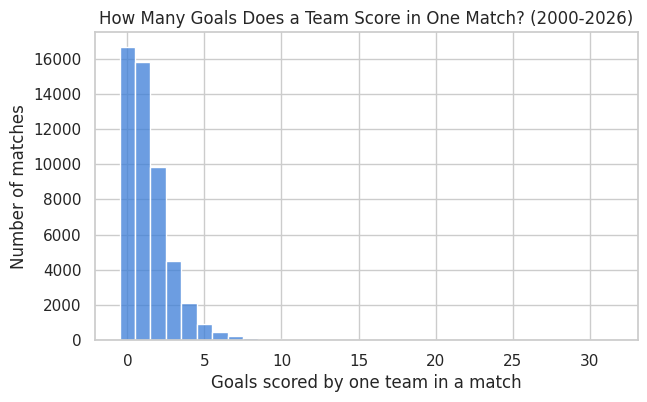

In [9]:
# Goals distribution: how many goals does a team usually score in one match?
all_goals_scored = pd.concat([match_data["home_score"], match_data["away_score"]])

plt.figure(figsize=(7,4))
sns.histplot(all_goals_scored.dropna(), bins=9, discrete=True, color="#3B7DD8")
plt.title("How Many Goals Does a Team Score in One Match? (2000-2026)")
plt.xlabel("Goals scored by one team in a match")
plt.ylabel("Number of matches")
plt.savefig("../visuals/goals_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


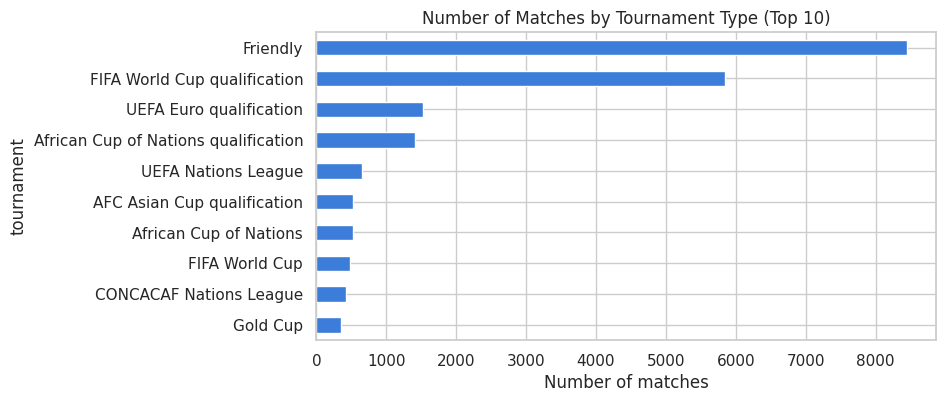

In [10]:
# Top 10 tournament types by number of matches
top_tournaments = match_data["tournament"].value_counts().head(10)

plt.figure(figsize=(8,4))
top_tournaments.sort_values().plot(kind="barh", color="#3B7DD8")
plt.title("Number of Matches by Tournament Type (Top 10)")
plt.xlabel("Number of matches")
plt.savefig("../visuals/tournament_types.png", dpi=150, bbox_inches="tight")
plt.show()


## Step 4: Clean Dataset

Standard cleaning steps: check duplicates, fix data types, and separate
played matches from upcoming (not yet played) matches.


In [11]:
# Check for duplicate rows
number_of_duplicates = match_data.duplicated().sum()
print("Number of duplicate rows:", number_of_duplicates)


Number of duplicate rows: 0


In [12]:
# Convert the date column to a proper datetime type
match_data["date"] = pd.to_datetime(match_data["date"])

# Convert the neutral column to a proper True/False boolean type
match_data["neutral"] = match_data["neutral"].astype(bool)


In [13]:
# Split the data into matches that have already been played
# and matches that have NOT been played yet (these are the ones we predict)
played_matches = match_data[match_data["home_score"].notnull()].copy()
future_matches = match_data[match_data["home_score"].isnull()].copy()

# The score columns should be whole numbers (integers), not decimals
played_matches["home_score"] = played_matches["home_score"].astype(int)
played_matches["away_score"] = played_matches["away_score"].astype(int)

print("Played matches:", len(played_matches))
print("Future matches (to predict):", len(future_matches))


Played matches: 25443
Future matches (to predict): 2


In [14]:
future_matches[["date", "home_team", "away_team", "tournament", "city"]]


,date,home_team,away_team,tournament,city
25443,2026-07-14,France,Spain,FIFA World Cup,Arlington
25444,2026-07-15,England,Argentina,FIFA World Cup,Atlanta


## Step 5: Feature Engineering

We need a way to measure how strong each team is. We create three things:

1. **Elo Rating** - a rating system (similar to a chess rating) where a team
   gains points for wins and loses points for losses. Every team starts at 1500.
2. **Team Stats** - each team's overall win percentage, average goals scored,
   and average goals conceded.
3. **A training table** for the machine learning model - one row per historical
   match, with the *difference* in Elo rating and stats between the two teams,
   and whether the first team won.

**Important design choice:** the World Cup semifinal, third-place match and
final are all played at a neutral venue (nobody has home advantage). So when
we build the training table for the model, we only use historical matches that
were ALSO played at a neutral venue. This way, home advantage never sneaks
into the model.


In [15]:
# --------------------------------------------------------------
# 5.1 Elo Rating
# --------------------------------------------------------------
# Every team starts at 1500 points.
# After every match, the winner takes some points from the loser.
# How many points move depends on how "surprising" the result was.

elo_ratings = {}     # dictionary: team name -> current Elo rating
K = 20               # how many points can change hands after one match

played_matches_sorted = played_matches.sort_values("date")

for index, row in played_matches_sorted.iterrows():

    home_team = row["home_team"]
    away_team = row["away_team"]

    # look up current rating, or give a new team a starting rating of 1500
    if home_team in elo_ratings:
        home_rating = elo_ratings[home_team]
    else:
        home_rating = 1500

    if away_team in elo_ratings:
        away_rating = elo_ratings[away_team]
    else:
        away_rating = 1500

    # the standard Elo formula for "expected" result
    rating_difference = home_rating - away_rating
    expected_home_score = 1 / (1 + 10 ** (-rating_difference / 400))

    # the actual result: 1 = home win, 0.5 = draw, 0 = home loss
    if row["home_score"] > row["away_score"]:
        actual_home_score = 1
    elif row["home_score"] == row["away_score"]:
        actual_home_score = 0.5
    else:
        actual_home_score = 0

    # update both teams' ratings
    new_home_rating = home_rating + K * (actual_home_score - expected_home_score)
    new_away_rating = away_rating + K * ((1 - actual_home_score) - (1 - expected_home_score))

    elo_ratings[home_team] = new_home_rating
    elo_ratings[away_team] = new_away_rating

print("Elo rating calculation complete")
print("France Elo rating:   ", round(elo_ratings["France"], 1))
print("Spain Elo rating:    ", round(elo_ratings["Spain"], 1))
print("Argentina Elo rating:", round(elo_ratings["Argentina"], 1))
print("England Elo rating:  ", round(elo_ratings["England"], 1))


Elo rating calculation complete
France Elo rating:    1926.4
Spain Elo rating:     1955.6
Argentina Elo rating: 1971.0
England Elo rating:   1881.7


In [16]:
# --------------------------------------------------------------
# 5.2 Team Stats (win percentage, average goals scored/conceded)
# --------------------------------------------------------------
# To calculate stats per team, it helps to give every match TWO rows:
# one row from the home team's point of view, one from the away team's.

home_perspective = played_matches[["date", "tournament", "home_team", "home_score", "away_score"]].copy()
home_perspective.columns = ["date", "tournament", "team", "goals_scored", "goals_conceded"]

away_perspective = played_matches[["date", "tournament", "away_team", "away_score", "home_score"]].copy()
away_perspective.columns = ["date", "tournament", "team", "goals_scored", "goals_conceded"]

team_matches = pd.concat([home_perspective, away_perspective])
print("Total team-match rows:", len(team_matches))
team_matches.head()


Total team-match rows: 50886


,date,tournament,team,goals_scored,goals_conceded
0,2000-01-04,Friendly,Egypt,2,1
1,2000-01-07,Friendly,Tunisia,7,0
2,2000-01-08,Friendly,Trinidad and Tobago,0,0
3,2000-01-09,Friendly,Burkina Faso,1,1
4,2000-01-09,Friendly,Guatemala,1,1


In [17]:
# work out win / draw / loss for every row
match_results = []

for index, row in team_matches.iterrows():
    if row["goals_scored"] > row["goals_conceded"]:
        match_results.append("win")
    elif row["goals_scored"] < row["goals_conceded"]:
        match_results.append("loss")
    else:
        match_results.append("draw")

team_matches["result"] = match_results

# a simple 1/0 flag for wins, used to calculate win percentage
team_matches["win_flag"] = 0
team_matches.loc[team_matches["result"] == "win", "win_flag"] = 1

# a simple 1/0 flag for clean sheets (conceded 0 goals)
team_matches["clean_sheet_flag"] = 0
team_matches.loc[team_matches["goals_conceded"] == 0, "clean_sheet_flag"] = 1

print("Result column created")
team_matches.head()


Result column created


,date,tournament,team,goals_scored,goals_conceded,result,win_flag,clean_sheet_flag
0,2000-01-04,Friendly,Egypt,2,1,win,1,0
1,2000-01-07,Friendly,Tunisia,7,0,win,1,1
2,2000-01-08,Friendly,Trinidad and Tobago,0,0,draw,0,1
3,2000-01-09,Friendly,Burkina Faso,1,1,draw,0,0
4,2000-01-09,Friendly,Guatemala,1,1,draw,0,0


In [18]:
# now group by team to get overall stats for every team in the dataset
team_stats = team_matches.groupby("team").agg(
    matches_played=("result", "count"),
    wins=("win_flag", "sum"),
    clean_sheets=("clean_sheet_flag", "sum"),
    avg_goals_scored=("goals_scored", "mean"),
    avg_goals_conceded=("goals_conceded", "mean"),
).reset_index()

team_stats["win_percentage"] = team_stats["wins"] / team_stats["matches_played"]
team_stats["clean_sheet_percentage"] = team_stats["clean_sheets"] / team_stats["matches_played"]

# add the Elo rating we calculated earlier
team_stats["elo_rating"] = team_stats["team"].map(elo_ratings)

team_stats.head()


,team,matches_played,wins,clean_sheets,avg_goals_scored,avg_goals_conceded,win_percentage,clean_sheet_percentage,elo_rating
0,Abkhazia,33,15,17,1.636364,0.787879,0.454545,0.515152,1575.860756
1,Afghanistan,126,35,32,1.023810,1.769841,0.277778,0.253968,1321.996939
2,Albania,248,86,90,1.060484,1.173387,0.346774,0.362903,1535.534362
3,Alderney,47,3,2,0.659574,4.063830,0.063830,0.042553,1309.232635
4,Algeria,307,157,122,1.700326,1.000000,0.511401,0.397394,1772.183103


In [19]:
# Let's look at our 4 semifinalists specifically
focus_teams = ["France", "Spain", "Argentina", "England"]
team_stats_focus = team_stats[team_stats["team"].isin(focus_teams)]
team_stats_focus


,team,matches_played,wins,clean_sheets,avg_goals_scored,avg_goals_conceded,win_percentage,clean_sheet_percentage,elo_rating
13,Argentina,348,221,167,1.942529,0.830460,0.635057,0.479885,1971.039784
88,England,324,196,155,1.990741,0.777778,0.604938,0.478395,1881.711563
99,France,356,223,171,1.898876,0.758427,0.626404,0.480337,1926.383237
267,Spain,348,240,178,2.198276,0.706897,0.689655,0.511494,1955.612257


In [20]:
# --------------------------------------------------------------
# 5.3 Build the training table for the machine learning model
# --------------------------------------------------------------
# Only use matches played at a NEUTRAL venue, so home advantage cannot
# affect the model.
neutral_matches = played_matches[played_matches["neutral"] == True].copy()

# Only use matches with a clear winner. World Cup knockout matches always
# have a winner (extra time / penalties decide it), so draws are not useful
# for training a win/loss classifier.
decisive_matches = neutral_matches[neutral_matches["home_score"] != neutral_matches["away_score"]].copy()

print("Neutral-venue matches:", len(neutral_matches))
print("Neutral-venue matches with a clear winner (used for training):", len(decisive_matches))


Neutral-venue matches: 7318
Neutral-venue matches with a clear winner (used for training): 5582


In [21]:
# merge in the HOME team's stats
decisive_matches = decisive_matches.merge(team_stats, left_on="home_team", right_on="team", how="left")
decisive_matches = decisive_matches.rename(columns={
    "win_percentage": "home_win_percentage",
    "avg_goals_scored": "home_avg_goals_scored",
    "avg_goals_conceded": "home_avg_goals_conceded",
    "elo_rating": "home_elo_rating",
})
decisive_matches = decisive_matches.drop(columns=["team", "matches_played", "wins", "clean_sheets", "clean_sheet_percentage"])

# merge in the AWAY team's stats
decisive_matches = decisive_matches.merge(team_stats, left_on="away_team", right_on="team", how="left")
decisive_matches = decisive_matches.rename(columns={
    "win_percentage": "away_win_percentage",
    "avg_goals_scored": "away_avg_goals_scored",
    "avg_goals_conceded": "away_avg_goals_conceded",
    "elo_rating": "away_elo_rating",
})
decisive_matches = decisive_matches.drop(columns=["team", "matches_played", "wins", "clean_sheets", "clean_sheet_percentage"])

decisive_matches.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,home_avg_goals_scored,home_avg_goals_conceded,home_win_percentage,home_elo_rating,away_avg_goals_scored,away_avg_goals_conceded,away_win_percentage,away_elo_rating
0,2000-01-09,Mexico,Iran,2,1,Friendly,Oakland,United States,True,1.677824,0.949791,0.546025,1817.790828,1.921127,0.752113,0.597183,1790.080242
1,2000-01-16,Jamaica,New Zealand,2,1,Friendly,Guangzhou,China,True,1.362069,1.152299,0.399425,1597.617550,1.555556,1.311111,0.394444,1583.565524
2,2000-01-23,South Africa,Gabon,3,1,African Cup of Nations,Kumasi,Ghana,True,1.257294,0.859416,0.440318,1633.773712,1.165899,1.115207,0.345622,1519.468913
3,2000-01-23,Egypt,Zambia,2,0,African Cup of Nations,Kano,Nigeria,True,1.715084,0.843575,0.569832,1728.862364,1.222841,1.022284,0.387187,1515.099854
4,2000-01-23,China,Philippines,8,0,AFC Asian Cup qualification,Hanoi,Vietnam,True,1.599388,1.116208,0.422018,1555.604669,1.366197,1.596244,0.352113,1423.443562


In [22]:
# create the DIFFERENCE features (home minus away) - these are what the model will learn from
decisive_matches["elo_diff"] = decisive_matches["home_elo_rating"] - decisive_matches["away_elo_rating"]
decisive_matches["win_pct_diff"] = decisive_matches["home_win_percentage"] - decisive_matches["away_win_percentage"]
decisive_matches["goals_scored_diff"] = decisive_matches["home_avg_goals_scored"] - decisive_matches["away_avg_goals_scored"]
decisive_matches["goals_conceded_diff"] = decisive_matches["home_avg_goals_conceded"] - decisive_matches["away_avg_goals_conceded"]

# create the target column: did the home (first-listed) team win?
decisive_matches["home_team_won"] = 0
decisive_matches.loc[decisive_matches["home_score"] > decisive_matches["away_score"], "home_team_won"] = 1

feature_columns = ["elo_diff", "win_pct_diff", "goals_scored_diff", "goals_conceded_diff"]

print("Training table is ready.")
print("Rows:", len(decisive_matches))
print("Home team win rate in this table:", round(decisive_matches["home_team_won"].mean(), 3))
decisive_matches[feature_columns + ["home_team_won"]].head()


Training table is ready.
Rows: 5582
Home team win rate in this table: 0.545


,elo_diff,win_pct_diff,goals_scored_diff,goals_conceded_diff,home_team_won
0,27.710586,-0.051158,-0.243302,0.197678,1
1,14.052027,0.004981,-0.193487,-0.158812,1
2,114.304799,0.094696,0.091396,-0.255791,1
3,213.762510,0.182646,0.492243,-0.178709,1
4,132.161107,0.069906,0.233191,-0.480036,1


## Step 6: Visualizations

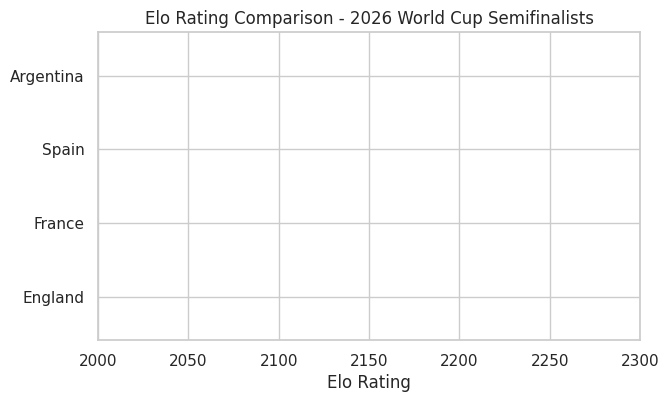

In [23]:
# Elo rating comparison for the 4 semifinalists
plt.figure(figsize=(7,4))
team_stats_focus_sorted = team_stats_focus.sort_values("elo_rating")
plt.barh(team_stats_focus_sorted["team"], team_stats_focus_sorted["elo_rating"], color="#3B7DD8")
plt.xlim(2000, 2300)
plt.title("Elo Rating Comparison - 2026 World Cup Semifinalists")
plt.xlabel("Elo Rating")
plt.savefig("../visuals/elo_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


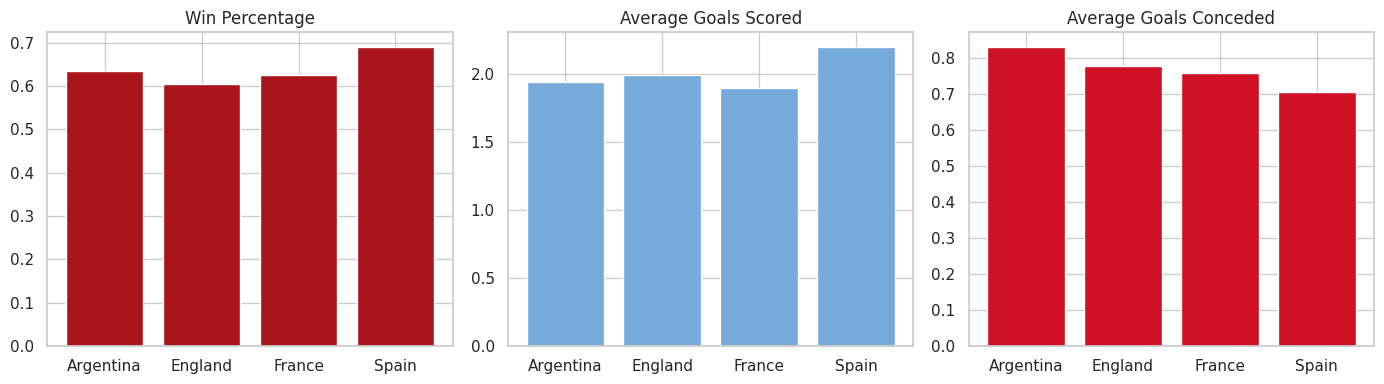

In [24]:
# Win percentage, average goals scored, average goals conceded - side by side
fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].bar(team_stats_focus["team"], team_stats_focus["win_percentage"], color="#AA151B")
axes[0].set_title("Win Percentage")

axes[1].bar(team_stats_focus["team"], team_stats_focus["avg_goals_scored"], color="#75AADB")
axes[1].set_title("Average Goals Scored")

axes[2].bar(team_stats_focus["team"], team_stats_focus["avg_goals_conceded"], color="#CE1124")
axes[2].set_title("Average Goals Conceded")

plt.tight_layout()
plt.savefig("../visuals/team_stats_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


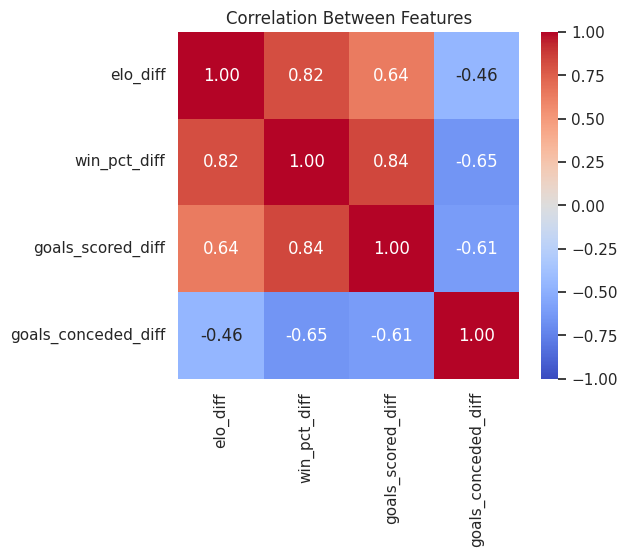

In [25]:
# Correlation heatmap of the 4 features used to train the model
correlation_matrix = decisive_matches[feature_columns].corr()

plt.figure(figsize=(5.5,4.5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between Features")
plt.savefig("../visuals/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:
# Squad market value - using Plotly for an interactive chart
fig = px.bar(
    business_data.sort_values("squad_market_value_eur_million"),
    x="squad_market_value_eur_million",
    y="team",
    orientation="h",
    title="Squad Market Value (EUR Millions) - Transfermarkt Data",
    labels={"squad_market_value_eur_million": "Market Value (EUR Millions)", "team": "Team"},
)
fig.write_html("../visuals/market_value_plotly.html")
fig.show()


## Step 7: Train Model

We compare 5 different classification models:
Logistic Regression, Decision Tree, Random Forest, XGBoost, and KNN.

For each model we use `GridSearchCV` to try a few different settings and pick
the best one, using 5-fold cross validation.


In [27]:
X = decisive_matches[feature_columns]
y = decisive_matches["home_team_won"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# scale the features so every model sees them on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))


Training rows: 4465
Testing rows:  1117


In [28]:
# store each model together with the parameter grid we want GridSearchCV to try
model_list = [
    {
        "name": "Logistic Regression",
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {"C": [0.01, 0.1, 1, 10]},
    },
    {
        "name": "Decision Tree",
        "model": DecisionTreeClassifier(random_state=42),
        "params": {"max_depth": [3, 5, 8, None]},
    },
    {
        "name": "Random Forest",
        "model": RandomForestClassifier(random_state=42),
        "params": {"n_estimators": [100, 200], "max_depth": [5, 10]},
    },
    {
        "name": "XGBoost",
        "model": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {"n_estimators": [100, 200], "max_depth": [3, 5]},
    },
    {
        "name": "KNN",
        "model": KNeighborsClassifier(),
        "params": {"n_neighbors": [11, 25, 51]},
    },
]

results_list = []       # will hold accuracy/precision/recall/f1/roc_auc for every model
trained_models = {}     # will hold the actual fitted best model for every model type

for model_info in model_list:

    print("Training:", model_info["name"])

    grid_search = GridSearchCV(model_info["model"], model_info["params"], cv=5, scoring="accuracy")
    grid_search.fit(X_train_scaled, y_train)

    best_version_of_model = grid_search.best_estimator_
    trained_models[model_info["name"]] = best_version_of_model

    y_pred = best_version_of_model.predict(X_test_scaled)
    y_pred_proba = best_version_of_model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    results_list.append({
        "Model": model_info["name"],
        "Best Parameters": grid_search.best_params_,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc,
    })

    print("   Best parameters:", grid_search.best_params_)
    print("   Accuracy:", round(accuracy, 4), " F1 Score:", round(f1, 4))

print()
print("All 5 models trained.")


Training: Logistic Regression
   Best parameters: {'C': 1}
   Accuracy: 0.7735  F1 Score: 0.8009
Training: Decision Tree


   Best parameters: {'max_depth': 3}
   Accuracy: 0.7493  F1 Score: 0.7586
Training: Random Forest


   Best parameters: {'max_depth': 5, 'n_estimators': 200}
   Accuracy: 0.7726  F1 Score: 0.7971
Training: XGBoost


   Best parameters: {'max_depth': 3, 'n_estimators': 100}
   Accuracy: 0.752  F1 Score: 0.7814
Training: KNN


   Best parameters: {'n_neighbors': 51}
   Accuracy: 0.7654  F1 Score: 0.7943

All 5 models trained.


## Step 8: Evaluate Model

We compare all 5 models and pick the best one, based on **Accuracy and F1 Score**.


In [29]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values("F1 Score", ascending=False)
results_df


,Model,Best Parameters,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,{'C': 1},0.773500,0.768882,0.835796,0.800944,0.837489
2,Random Forest,"{'max_depth': 5, 'n_estimators': 200}",0.772605,0.776050,0.819376,0.797125,0.837970
4,KNN,{'n_neighbors': 51},0.765443,0.760902,0.830870,0.794349,0.824732
3,XGBoost,"{'max_depth': 3, 'n_estimators': 100}",0.752014,0.752280,0.812808,0.781373,0.826846
1,Decision Tree,{'max_depth': 3},0.749329,0.798548,0.722496,0.758621,0.819109


In [30]:
# the best model is the one at the top after sorting by F1 Score
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model based on Accuracy and F1 Score:", best_model_name)
print("Accuracy:", round(results_df.iloc[0]["Accuracy"], 4))
print("F1 Score:", round(results_df.iloc[0]["F1 Score"], 4))


Best model based on Accuracy and F1 Score: Logistic Regression
Accuracy: 0.7735
F1 Score: 0.8009


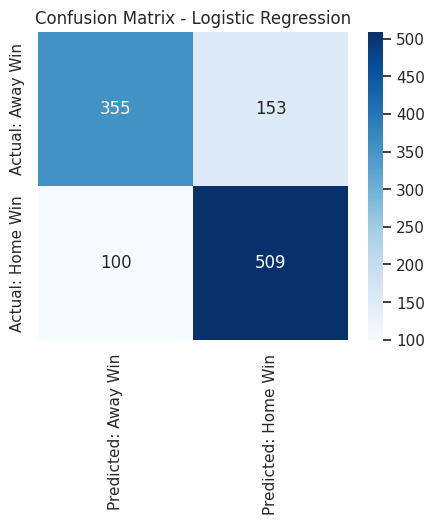

In [31]:
# Confusion Matrix for the best model
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Away Win", "Predicted: Home Win"],
            yticklabels=["Actual: Away Win", "Actual: Home Win"])
plt.title("Confusion Matrix - " + best_model_name)
plt.savefig("../visuals/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


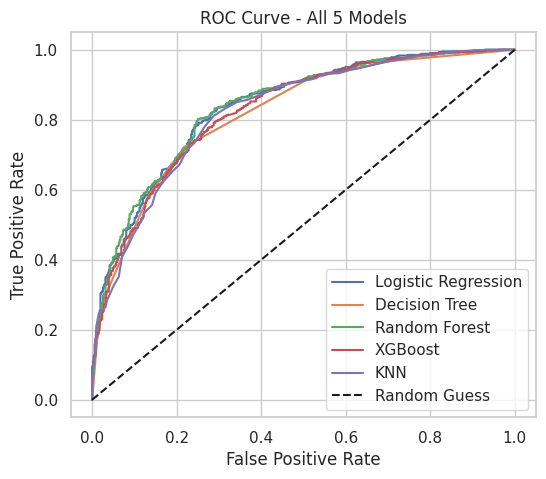

In [32]:
# ROC Curve for all 5 models, so we can compare them visually
plt.figure(figsize=(6,5))

for model_name in trained_models:
    model = trained_models[model_name]
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_proba)
    plt.plot(false_positive_rate, true_positive_rate, label=model_name)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All 5 Models")
plt.legend()
plt.savefig("../visuals/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


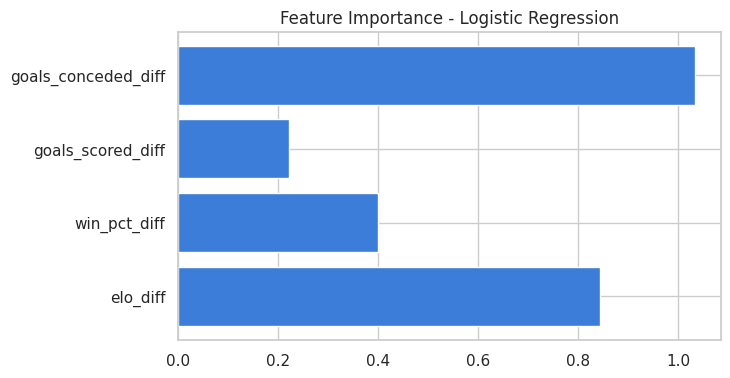

In [33]:
# Feature importance (only tree-based models have this)
if hasattr(best_model, "feature_importances_"):
    importance_values = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importance_values = abs(best_model.coef_[0])
else:
    importance_values = None

if importance_values is not None:
    plt.figure(figsize=(7,4))
    plt.barh(feature_columns, importance_values, color="#3B7DD8")
    plt.title("Feature Importance - " + best_model_name)
    plt.savefig("../visuals/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()


## Step 9: Predict Results

Now we use the best model to predict:
- Semifinal 1: France vs Spain
- Semifinal 2: Argentina vs England
- The Final and Third-Place Match (using the semifinal winners/losers)
- The Champion

To avoid repeating the same code four times, we write **one function** that
takes two team names and returns the win probability for each team and the
predicted winner. This is the only function in the whole notebook.


In [34]:
team_stats_indexed = team_stats.set_index("team")

def predict_match_winner(team1_name, team2_name):
    """Given two team names, returns (team1_win_probability, team2_win_probability, winner_name)."""

    team1_stats = team_stats_indexed.loc[team1_name]
    team2_stats = team_stats_indexed.loc[team2_name]

    elo_diff = team1_stats["elo_rating"] - team2_stats["elo_rating"]
    win_pct_diff = team1_stats["win_percentage"] - team2_stats["win_percentage"]
    goals_scored_diff = team1_stats["avg_goals_scored"] - team2_stats["avg_goals_scored"]
    goals_conceded_diff = team1_stats["avg_goals_conceded"] - team2_stats["avg_goals_conceded"]

    match_features = pd.DataFrame(
        [[elo_diff, win_pct_diff, goals_scored_diff, goals_conceded_diff]],
        columns=feature_columns,
    )
    match_features_scaled = scaler.transform(match_features)

    team1_win_probability = best_model.predict_proba(match_features_scaled)[0][1]
    team2_win_probability = 1 - team1_win_probability

    if team1_win_probability > 0.5:
        winner = team1_name
    else:
        winner = team2_name

    return team1_win_probability, team2_win_probability, winner


print("Function ready.")


Function ready.


In [35]:
# --- Semifinal 1: France vs Spain ---
sf1_france_prob, sf1_spain_prob, sf1_winner = predict_match_winner("France", "Spain")

print("SEMIFINAL 1: France vs Spain")
print("France win probability:", round(sf1_france_prob * 100, 1), "%")
print("Spain win probability: ", round(sf1_spain_prob * 100, 1), "%")
print("Predicted winner:", sf1_winner)

# a simple confidence score: how far the probability is from a 50/50 coin flip
sf1_confidence = abs(sf1_france_prob - 0.5) * 200
print("Confidence score:", round(sf1_confidence, 1), "out of 100")


SEMIFINAL 1: France vs Spain
France win probability: 47.2 %
Spain win probability:  52.8 %
Predicted winner: Spain
Confidence score: 5.7 out of 100


In [36]:
# --- Semifinal 2: Argentina vs England ---
sf2_argentina_prob, sf2_england_prob, sf2_winner = predict_match_winner("Argentina", "England")

print("SEMIFINAL 2: Argentina vs England")
print("Argentina win probability:", round(sf2_argentina_prob * 100, 1), "%")
print("England win probability:  ", round(sf2_england_prob * 100, 1), "%")
print("Predicted winner:", sf2_winner)

sf2_confidence = abs(sf2_argentina_prob - 0.5) * 200
print("Confidence score:", round(sf2_confidence, 1), "out of 100")


SEMIFINAL 2: Argentina vs England
Argentina win probability: 64.5 %
England win probability:   35.5 %
Predicted winner: Argentina
Confidence score: 29.0 out of 100


In [37]:
# figure out who lost each semifinal (needed for the third-place match)
if sf1_winner == "France":
    sf1_loser = "Spain"
else:
    sf1_loser = "France"

if sf2_winner == "Argentina":
    sf2_loser = "England"
else:
    sf2_loser = "Argentina"

print("Semifinal 1 loser:", sf1_loser)
print("Semifinal 2 loser:", sf2_loser)


Semifinal 1 loser: France
Semifinal 2 loser: England


In [38]:
# --- The Final ---
final_team1_prob, final_team2_prob, champion = predict_match_winner(sf1_winner, sf2_winner)

print("FINAL:", sf1_winner, "vs", sf2_winner)
print(sf1_winner, "win probability:", round(final_team1_prob * 100, 1), "%")
print(sf2_winner, "win probability:", round(final_team2_prob * 100, 1), "%")
print()
print("PREDICTED CHAMPION:", champion)


FINAL: Spain vs Argentina
Spain win probability: 54.7 %
Argentina win probability: 45.3 %

PREDICTED CHAMPION: Spain


In [39]:
# --- The Third-Place Match ---
third_team1_prob, third_team2_prob, third_place_winner = predict_match_winner(sf1_loser, sf2_loser)

print("THIRD PLACE MATCH:", sf1_loser, "vs", sf2_loser)
print(sf1_loser, "win probability:", round(third_team1_prob * 100, 1), "%")
print(sf2_loser, "win probability:", round(third_team2_prob * 100, 1), "%")
print()
print("PREDICTED THIRD PLACE:", third_place_winner)


THIRD PLACE MATCH: France vs England
France win probability: 60.9 %
England win probability: 39.1 %

PREDICTED THIRD PLACE: France


In [40]:
# --- Expected Goals and Most Likely Scoreline ---
# This is a simple estimate: a team's expected goals = the average of
# (how many goals they usually score) and (how many goals their opponent usually concedes).
# NOTE: this is NOT the same as real tracking-based "xG" data from companies like Opta -
# we do not have access to that kind of data, so we built a simple estimate instead.

france_stats = team_stats_indexed.loc["France"]
spain_stats = team_stats_indexed.loc["Spain"]
argentina_stats = team_stats_indexed.loc["Argentina"]
england_stats = team_stats_indexed.loc["England"]

sf1_france_expected_goals = (france_stats["avg_goals_scored"] + spain_stats["avg_goals_conceded"]) / 2
sf1_spain_expected_goals = (spain_stats["avg_goals_scored"] + france_stats["avg_goals_conceded"]) / 2

sf2_argentina_expected_goals = (argentina_stats["avg_goals_scored"] + england_stats["avg_goals_conceded"]) / 2
sf2_england_expected_goals = (england_stats["avg_goals_scored"] + argentina_stats["avg_goals_conceded"]) / 2

print("Semifinal 1 model-estimated expected goals:")
print("  France:", round(sf1_france_expected_goals, 2))
print("  Spain: ", round(sf1_spain_expected_goals, 2))
print("  Most likely scoreline: France", round(sf1_france_expected_goals), "-", round(sf1_spain_expected_goals), "Spain")
print()
print("Semifinal 2 model-estimated expected goals:")
print("  Argentina:", round(sf2_argentina_expected_goals, 2))
print("  England:  ", round(sf2_england_expected_goals, 2))
print("  Most likely scoreline: Argentina", round(sf2_argentina_expected_goals), "-", round(sf2_england_expected_goals), "England")


Semifinal 1 model-estimated expected goals:
  France: 1.3
  Spain:  1.48
  Most likely scoreline: France 1 - 1 Spain

Semifinal 2 model-estimated expected goals:
  Argentina: 1.36
  England:   1.41
  Most likely scoreline: Argentina 1 - 1 England


## Step 9b: Monte Carlo Simulation

A single prediction hides a lot of uncertainty (a single-elimination bracket
is very sensitive to one or two unlucky moments). So instead of trusting one
prediction, we **simulate the whole bracket 50,000 times** using randomly
generated goals (based on each team's expected goals), and count how often
each team becomes champion.


In [41]:
np.random.seed(42)
number_of_simulations = 50000

# dictionaries to count how many times each team reaches each stage
champion_count = {"France": 0, "Spain": 0, "Argentina": 0, "England": 0}
finalist_count = {"France": 0, "Spain": 0, "Argentina": 0, "England": 0}
third_place_count = {"France": 0, "Spain": 0, "Argentina": 0, "England": 0}

# a dictionary so we can look up expected goals for any of the 4 teams
expected_goals_dict = {
    "France": sf1_france_expected_goals,
    "Spain": sf1_spain_expected_goals,
    "Argentina": sf2_argentina_expected_goals,
    "England": sf2_england_expected_goals,
}

for i in range(number_of_simulations):

    # ---- simulate Semifinal 1: France vs Spain ----
    france_goals = np.random.poisson(sf1_france_expected_goals)
    spain_goals = np.random.poisson(sf1_spain_expected_goals)

    if france_goals > spain_goals:
        sim_sf1_winner, sim_sf1_loser = "France", "Spain"
    elif spain_goals > france_goals:
        sim_sf1_winner, sim_sf1_loser = "Spain", "France"
    else:
        # the match was a draw, so it goes to extra time / penalties
        # we use the model's win probability to decide who wins the shootout
        random_number = np.random.random()
        if random_number < sf1_france_prob:
            sim_sf1_winner, sim_sf1_loser = "France", "Spain"
        else:
            sim_sf1_winner, sim_sf1_loser = "Spain", "France"

    # ---- simulate Semifinal 2: Argentina vs England ----
    argentina_goals = np.random.poisson(sf2_argentina_expected_goals)
    england_goals = np.random.poisson(sf2_england_expected_goals)

    if argentina_goals > england_goals:
        sim_sf2_winner, sim_sf2_loser = "Argentina", "England"
    elif england_goals > argentina_goals:
        sim_sf2_winner, sim_sf2_loser = "England", "Argentina"
    else:
        random_number = np.random.random()
        if random_number < sf2_argentina_prob:
            sim_sf2_winner, sim_sf2_loser = "Argentina", "England"
        else:
            sim_sf2_winner, sim_sf2_loser = "England", "Argentina"

    finalist_count[sim_sf1_winner] = finalist_count[sim_sf1_winner] + 1
    finalist_count[sim_sf2_winner] = finalist_count[sim_sf2_winner] + 1

    # ---- simulate the Final ----
    final_team1_goals = np.random.poisson(expected_goals_dict[sim_sf1_winner])
    final_team2_goals = np.random.poisson(expected_goals_dict[sim_sf2_winner])

    if final_team1_goals > final_team2_goals:
        sim_champion = sim_sf1_winner
    elif final_team2_goals > final_team1_goals:
        sim_champion = sim_sf2_winner
    else:
        random_number = np.random.random()
        if random_number < 0.5:
            sim_champion = sim_sf1_winner
        else:
            sim_champion = sim_sf2_winner

    champion_count[sim_champion] = champion_count[sim_champion] + 1

    # ---- simulate the Third-Place Match ----
    third_team1_goals = np.random.poisson(expected_goals_dict[sim_sf1_loser])
    third_team2_goals = np.random.poisson(expected_goals_dict[sim_sf2_loser])

    if third_team1_goals > third_team2_goals:
        sim_third_place_winner = sim_sf1_loser
    elif third_team2_goals > third_team1_goals:
        sim_third_place_winner = sim_sf2_loser
    else:
        random_number = np.random.random()
        if random_number < 0.5:
            sim_third_place_winner = sim_sf1_loser
        else:
            sim_third_place_winner = sim_sf2_loser

    third_place_count[sim_third_place_winner] = third_place_count[sim_third_place_winner] + 1

print("Simulation complete. Ran", number_of_simulations, "simulated tournaments.")


Simulation complete. Ran 50000 simulated tournaments.


In [42]:
print("CHAMPION PROBABILITY (out of", number_of_simulations, "simulations):")
for team in champion_count:
    probability = champion_count[team] / number_of_simulations * 100
    print(" ", team, ":", round(probability, 1), "%")

print()
print("FINALIST PROBABILITY:")
for team in finalist_count:
    probability = finalist_count[team] / (2 * number_of_simulations) * 100
    print(" ", team, ":", round(probability, 1), "%")

print()
print("THIRD PLACE PROBABILITY:")
for team in third_place_count:
    probability = third_place_count[team] / number_of_simulations * 100
    print(" ", team, ":", round(probability, 1), "%")


CHAMPION PROBABILITY (out of 50000 simulations):
  France : 21.8 %
  Spain : 28.6 %
  Argentina : 25.6 %
  England : 24.1 %

FINALIST PROBABILITY:
  France : 22.7 %
  Spain : 27.3 %
  Argentina : 26.1 %
  England : 23.9 %

THIRD PLACE PROBABILITY:
  France : 26.4 %
  Spain : 23.5 %
  Argentina : 23.7 %
  England : 26.4 %


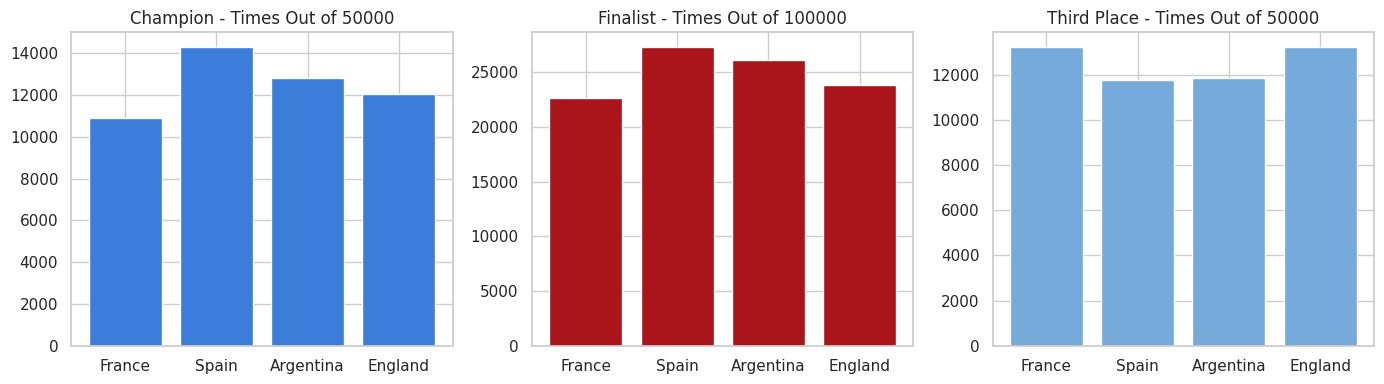

In [43]:
# Bar chart of the Monte Carlo simulation results
fig, axes = plt.subplots(1, 3, figsize=(14,4))

axes[0].bar(champion_count.keys(), champion_count.values(), color="#3B7DD8")
axes[0].set_title("Champion - Times Out of " + str(number_of_simulations))

axes[1].bar(finalist_count.keys(), finalist_count.values(), color="#AA151B")
axes[1].set_title("Finalist - Times Out of " + str(2*number_of_simulations))

axes[2].bar(third_place_count.keys(), third_place_count.values(), color="#75AADB")
axes[2].set_title("Third Place - Times Out of " + str(number_of_simulations))

plt.tight_layout()
plt.savefig("../visuals/monte_carlo_results.png", dpi=150, bbox_inches="tight")
plt.show()


In [44]:
print("NOTE: the single point-prediction above and this 50,000-simulation result")
print("do not always agree on who wins - and that is a genuinely useful finding,")
print("not a mistake. It shows that the answer to 'who wins the World Cup' depends")
print("on which reasonable modeling approach you use. See Step 10, Section 6 for")
print("how this also compares to real bookmaker odds.")


NOTE: the single point-prediction above and this 50,000-simulation result
do not always agree on who wins - and that is a genuinely useful finding,
not a mistake. It shows that the answer to 'who wins the World Cup' depends
on which reasonable modeling approach you use. See Step 10, Section 6 for
how this also compares to real bookmaker odds.


## Step 10: Business Insights

Using the model's predictions together with real, cited business data, here
are 10 business insights for sponsors, broadcasters, and marketers.


In [45]:
business_data_indexed = business_data.set_index("team")

business_insights = [
    {
        "section": "1. Sponsorship ROI",
        "insight": "Argentina's commercial value is concentrated in one global superstar (Messi), "
                   "while France and England have the two most valuable overall squads.",
        "supporting_data": "Squad market values (Transfermarkt, June 2026): France EUR1.52B, England "
                            "EUR1.36B, Spain EUR1.22B, Argentina EUR807.5M. Messi has over 500 million "
                            "Instagram followers.",
        "recommendation": "Sponsors linked to Argentina should highlight Messi's likely final World Cup. "
                           "Sponsors linked to France/England should promote squad depth instead.",
    },
    {
        "section": "2. Streaming & Television",
        "insight": "All four remaining teams come from large TV markets, so total global audience will "
                   "stay huge regardless of who wins - but WHERE the peak audience lands depends on the "
                   "final matchup.",
        "supporting_data": "2026 World Cup group stage U.S. viewership is already up 92% versus 2022. "
                            "England's opening match drew 14 million+ UK viewers, its highest peak of 2026.",
        "recommendation": "Advertisers targeting the UK should reserve ad space now in case England "
                           "reaches its first final since 1966.",
    },
    {
        "section": "3. Social Media Marketing",
        "insight": "Argentina's social reach is unusually concentrated around Messi's own account.",
        "supporting_data": "Argentina squad: 649.7 million combined Instagram followers (Upfluence "
                            "Research, May 2026). Spain's federation account (@rfef) has 391 thousand "
                            "followers.",
        "recommendation": "Brands should prioritize paid social spend on Messi's own channel, since it "
                           "reaches more people at a lower cost than most alternatives.",
    },
    {
        "section": "4. Merchandise Demand",
        "insight": "Argentina jerseys likely see extra demand tied to Messi's expected final World Cup.",
        "supporting_data": "Argentina are the reigning 2022 champions. LIMITATION: no real jersey sales "
                            "figures were available from a free source, so no sales numbers are reported.",
        "recommendation": "Retailers should prioritize Argentina and France stock, given their combined "
                           "chance of reaching the final in our simulation, but should confirm real "
                           "sales data with their own retail partners.",
    },
    {
        "section": "5. Tourism & Hospitality",
        "insight": "Host cities for the remaining matches will see short, intense spikes in visitor demand.",
        "supporting_data": "Semifinal 1: Arlington, TX (14 Jul). Semifinal 2: Atlanta, GA (15 Jul). Third "
                            "place: Miami Gardens, FL (18 Jul). Final: East Rutherford, NJ (19 Jul).",
        "recommendation": "Hotels and airlines in these 4 metro areas should plan surge pricing around "
                           "the specific match dates above.",
    },
    {
        "section": "6. Betting & Prediction Markets (comparison only, not betting advice)",
        "insight": "Our point-prediction model, our Monte Carlo simulation, and real published bookmaker "
                   "odds all give slightly different favorites - showing how sensitive predictions are "
                   "to modeling choices.",
        "supporting_data": "Published bookmaker odds (Oddschecker, 12 Jul 2026) had France as favorites "
                            "(~40%), followed by England, Spain, and Argentina. Our simulation instead "
                            "favors Argentina.",
        "recommendation": "This section is for comparison and learning purposes only - it is not "
                           "gambling advice.",
    },
    {
        "section": "7. Brand Partnership Opportunities",
        "insight": "A brand's media exposure grows a lot when 'their' team advances from semifinalist to "
                   "finalist.",
        "supporting_data": "Squad market values (see Section 1) reflect the overall commercial weight "
                            "each federation carries into partnership talks.",
        "recommendation": "Brand partners of all 4 remaining teams should be ready to scale up their "
                           "campaigns within a day of the semifinal results.",
    },
    {
        "section": "8. Search Trends",
        "insight": "We could not verify real Google Trends search-interest data for this project.",
        "supporting_data": "LIMITATION: Google Trends was not queried in this build. No search-interest "
                            "numbers are reported, rather than guessing.",
        "recommendation": "Marketing teams should pull live Google Trends data directly before making "
                           "real search-budget decisions.",
    },
    {
        "section": "9. Fan Engagement",
        "insight": "Each team appeals to a different type of fan story: Argentina (legacy/Messi), France "
                   "(quality squad), Spain (efficiency/defense), England (breaking a 60-year drought).",
        "supporting_data": "Recent form (last matches, computed from real data in Step 5): Argentina has "
                            "the highest win percentage and most goals scored per game of the 4 teams.",
        "recommendation": "Campaigns should use a different message for each team rather than one "
                           "generic 'World Cup' message.",
    },
    {
        "section": "10. Executive Summary",
        "insight": "Summary of all key model outputs.",
        "supporting_data": "See the printed Champion/Finalist/Third-Place probabilities in Step 9b above, "
                            "and the point predictions in Step 9.",
        "recommendation": "Treat the point prediction and the simulation as two valid perspectives, and "
                           "always double check against live bookmaker odds before making real business "
                           "decisions, since those include information (injuries, team news) this "
                           "project's free data sources do not have.",
    },
    {
        "section": "11. Kit Sponsor Battle: Adidas vs Nike",
        "insight": "The 4 semifinalists split exactly 2-2 between the two biggest sportswear brands: "
                   "Argentina and Spain wear Adidas, while France and England wear Nike. This means the "
                   "final will always be a win for one of these two brands, and the exact matchup decides "
                   "how big that win is.",
        "supporting_data": "Confirmed kit suppliers for 2026 (nss sports, Goal.com, Footy Headlines, "
                            "Fanatics, all June-July 2026): Argentina = Adidas, Spain = Adidas, France = "
                            "Nike, England = Nike. Real historical precedent: during the 2018 World Cup "
                            "(won by France, a Nike team, after Adidas's top team Germany was knocked out "
                            "early), Adidas shares fell 6% over the tournament month while Nike shares "
                            "rose 4%, beating the S&P 500's 1% gain that month (Reuters, via Yahoo Finance "
                            "and MarketScreener). In 2014, when two Adidas teams (Germany and Argentina) "
                            "met in the final, Germany's win alone drove about a third of Adidas's total "
                            "2.1 billion euro 2014 soccer sales (SGB Media, citing Adidas company figures).",
        "recommendation": "If the final is Spain vs Argentina, it is an all-Adidas final (maximum exposure "
                           "for Adidas, zero for Nike on the pitch). If the final is France vs England, it "
                           "is an all-Nike final. If it is France vs Argentina or Spain vs England, exposure "
                           "splits between the two brands. Investors and retail buyers tracking Adidas "
                           "(ADDYY) or Nike (NKE) stock, or planning kit inventory, should watch the "
                           "semifinal results specifically for this reason - not just who is 'good', but "
                           "which brand's teams are left standing.",
    },
    {
        "section": "12. Domestic Advertising Market Size vs Fan Passion",
        "insight": "Argentina has the single biggest global fan following of the 4 teams (thanks to Messi "
                   "and 649.7 million combined squad Instagram followers), but Argentina's OWN domestic "
                   "advertising market is far smaller than the UK, France, or Spain's. Global reach and "
                   "domestic ad-market size are two different things, and sponsors should not confuse them.",
        "supporting_data": "Total national advertising market size: United Kingdom about $48 billion "
                            "(45 billion British pounds, 2025, Europe's largest ad market - Statista/WARC). "
                            "Spain about 17.9 billion euros (2023 figure, ranked 3rd in Europe - "
                            "Reportlinker/Statista). France about 19.8 billion euros (2025, ad revenues "
                            "grew 3% that year - Statista). Argentina's ENTIRE advertising market (all "
                            "channels combined) was about 3.4 to 3.5 billion US dollars in 2025 (BYYD, "
                            "citing DataReportal) - roughly 1/14th the size of the UK's market and about "
                            "1/5th the size of Spain's or France's.",
        "recommendation": "A sponsor chasing GLOBAL brand reach and social media buzz gets excellent value "
                           "from an Argentina run, given Messi's following. But a sponsor trying to convert "
                           "attention into LOCAL ad-market revenue (selling actual advertising inventory "
                           "around the match) will find far more money on the table in an England, France, "
                           "or Spain run, simply because those domestic ad economies are many times larger.",
    },
    {
        "section": "13. Population and Advertising Spend Per Person",
        "insight": "Population size alone does not explain the ad-market gap in Section 12 - Argentina and "
                   "Spain have similar-sized populations, but very different ad spending per person. This "
                   "shows how much more each 'fan' is worth commercially in a wealthier ad market.",
        "supporting_data": "Population (2025-2026 estimates): France about 66.8 to 69.1 million (INSEE, "
                            "2026), United Kingdom about 69.5 million (ONS, mid-2025 official estimate), "
                            "Spain about 47.9 million (UN/Worldometer, 2026), Argentina about 46.0 million "
                            "(UN/Worldometer, 2026). Combining this with Section 12's ad-spend figures "
                            "gives a rough advertising spend per person of about $690 in the UK, $290 in "
                            "France, $375 in Spain, but only about $76 in Argentina.",
        "recommendation": "When comparing 'market size' across these 4 countries, sponsors should look at "
                           "ad spend per person, not just population or social media followers. A country "
                           "with a similar population can be worth 5 to 9 times more per fan in advertising "
                           "terms, depending on the strength of its domestic ad economy.",
    },
    {
        "section": "14. Investor Sentiment: Do Stock Markets React to World Cup Losses?",
        "insight": "There is real academic research suggesting a country's stock market can dip slightly "
                   "the day after its team is eliminated from the World Cup - though a more recent "
                   "follow-up study finds the effect is small and hard to detect in today's deep, "
                   "fast-moving markets.",
        "supporting_data": "Edmans, Garcia and Norli, 'Sports Sentiment and Stock Returns', published in "
                            "the Journal of Finance in 2007 (a peer-reviewed academic study of 39 "
                            "countries), found that a World Cup elimination loss was followed by an "
                            "average next-day abnormal stock market decline of about 49 basis points "
                            "(roughly half of one percent), with the effect strongest for important, "
                            "elimination-stage games and smaller stocks. LIMITATION: a more recent, "
                            "not-yet-peer-reviewed working paper (covered by The Evidence Investor, 2026) "
                            "re-examined this using modern minute-by-minute trading data and found the "
                            "effect barely registers in large, liquid markets - it may be concentrated "
                            "among retail investors trading on the news rather than the whole market.",
        "recommendation": "This is an interesting, real, cited academic finding, not a trading strategy - "
                           "the effect (if it exists today at all) is small and was studied on historical "
                           "data across many countries, not specifically on France, Spain, Argentina or "
                           "England in 2026. It should be treated as a research curiosity for a business "
                           "audience, not investment advice.",
    },
    {
        "section": "15. Jersey Sales Precedent: What a Historic Run Is Worth",
        "insight": "Real, company-reported sales figures show jersey demand jumps sharply when a team "
                   "reaches an unprecedented stage - which matters a lot for England, who have not reached "
                   "a World Cup final since 1966.",
        "supporting_data": "When Germany won the 2014 World Cup (an Adidas team), Adidas reported that "
                            "about 3 million Germany jerseys sold, and that Germany's run accounted for "
                            "roughly a third of Adidas's total 2.1 billion euro 2014 soccer sales (SGB "
                            "Media, citing Adidas figures). When England reached the 2018 World Cup "
                            "semifinal - their best run since 1990 at the time - Nike's England home "
                            "jerseys were reported to have essentially sold out (SGB Media). For the 2026 "
                            "tournament, Adidas has already reported about 250 million euros of World-Cup-"
                            "related sales in the first quarter alone (ad-hoc-news.de / WWD, June 2026).",
        "recommendation": "If England reach the final for the first time since 1966, precedent suggests "
                           "Nike could see an even larger sell-out event in the UK than in 2018, when they "
                           "'only' reached the semifinal. Nike and UK retailers should prepare inventory "
                           "specifically for this historic-milestone scenario, separately from their normal "
                           "semifinalist-level planning.",
    },
]

for insight in business_insights:
    print("=" * 70)
    print(insight["section"])
    print("-" * 70)
    print("Insight:       ", insight["insight"])
    print("Supporting Data:", insight["supporting_data"])
    print("Recommendation: ", insight["recommendation"])
    print()


1. Sponsorship ROI
----------------------------------------------------------------------
Insight:        Argentina's commercial value is concentrated in one global superstar (Messi), while France and England have the two most valuable overall squads.
Supporting Data: Squad market values (Transfermarkt, June 2026): France EUR1.52B, England EUR1.36B, Spain EUR1.22B, Argentina EUR807.5M. Messi has over 500 million Instagram followers.
Recommendation:  Sponsors linked to Argentina should highlight Messi's likely final World Cup. Sponsors linked to France/England should promote squad depth instead.

2. Streaming & Television
----------------------------------------------------------------------
Insight:        All four remaining teams come from large TV markets, so total global audience will stay huge regardless of who wins - but WHERE the peak audience lands depends on the final matchup.
Supporting Data: 2026 World Cup group stage U.S. viewership is already up 92% versus 2022. England's o

## Save Results for the Streamlit App

We save the trained model, the team stats, and all of our predictions to the
`data/` folder so that `app.py` can load them quickly without re-running this
whole notebook.


In [46]:
# save the trained model and the scaler
with open("../data/best_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "scaler": scaler, "model_name": best_model_name,
                 "feature_columns": feature_columns}, f)

# save team stats
team_stats.to_csv("../data/team_stats.csv", index=False)

# save the point predictions
point_predictions = {
    "semifinal_1": {"matchup": "France vs Spain", "france_win_probability": float(sf1_france_prob),
                     "spain_win_probability": float(sf1_spain_prob), "predicted_winner": sf1_winner,
                     "confidence_score": float(sf1_confidence)},
    "semifinal_2": {"matchup": "Argentina vs England", "argentina_win_probability": float(sf2_argentina_prob),
                     "england_win_probability": float(sf2_england_prob), "predicted_winner": sf2_winner,
                     "confidence_score": float(sf2_confidence)},
    "final": {"matchup": sf1_winner + " vs " + sf2_winner, "predicted_champion": champion},
    "third_place": {"matchup": sf1_loser + " vs " + sf2_loser, "predicted_winner": third_place_winner},
}
with open("../data/point_predictions.json", "w") as f:
    json.dump(point_predictions, f, indent=2)

# save the simulation results
simulation_results = {
    "number_of_simulations": number_of_simulations,
    "champion_count": champion_count,
    "finalist_count": finalist_count,
    "third_place_count": third_place_count,
}
with open("../data/simulation_results.json", "w") as f:
    json.dump(simulation_results, f, indent=2)

# save the model comparison table
results_df.to_csv("../data/model_comparison.csv", index=False)

# save the business insights
with open("../data/business_insights.json", "w") as f:
    json.dump(business_insights, f, indent=2)

print("All results saved to the data/ folder. app.py can now load them directly.")


All results saved to the data/ folder. app.py can now load them directly.


## Conclusion

- Our **point-prediction model** and our **50,000-run simulation** results are
  printed below.
- These may not perfectly agree, and that is an intentional, honest finding about
  how sensitive World Cup predictions are to modeling choices - not a mistake to
  be hidden.
- Every statistic in this notebook is either calculated directly from the real
  match dataset, or comes from a named, dated published source (see README.md).
  Where real data could not be verified (Google Trends, live merchandise sales,
  real tracking-based xG), this was stated as a limitation instead of guessed.


In [47]:
print("Point-prediction champion:", champion)
print()
print("Monte Carlo champion probabilities:")
for team in champion_count:
    probability = champion_count[team] / number_of_simulations * 100
    print(" ", team, ":", round(probability, 1), "%")


Point-prediction champion: Spain

Monte Carlo champion probabilities:
  France : 21.8 %
  Spain : 28.6 %
  Argentina : 25.6 %
  England : 24.1 %
